# [plot-log-files.ipynb](https://github.com/lafefspietz/bluefors-fridge-log-server/blob/main/copy-log-files.ipynb)

[Jupyter notebook](https://jupyter.org/) to plot log files from Bluefors fridge data, which is copied using the notebook [copy-log-files.ipynb](https://github.com/lafefspietz/bluefors-fridge-log-server/blob/main/copy-log-files.ipynb).

In [29]:
import os
import datetime
import json
import time
import matplotlib.pyplot as plt
import numpy as np

In [56]:
# fetch local logfolders and list them
logfolders = os.listdir('logfolders')
logfolders

['26-05-10',
 '26-05-11',
 '26-05-12',
 '26-05-13',
 '26-05-14',
 '26-05-15',
 '26-05-16',
 '26-05-17',
 '26-05-18',
 '26-05-19',
 '26-05-20']

In [8]:
logfolder = logfolders[len(logfolders) - 1]

In [9]:
logfolder

'26-05-20'

In [54]:
logs = os.listdir('logfolders/' + logfolder)
logdata = {}
for log in logs:
    if 'CH1 T' in log:
        f = open('logfolders/' + logfolder + '/' + log)
        rawdata = f.read()
        f.close()
        datalist = rawdata.split('\n')
        logdata['50kplate'] = {}
        logdata['50kplate']['date'] = datalist[0].split(',')[0]
        logdata['50kplate']['time'] = []
        logdata['50kplate']['temperature'] = []
        for dataline in datalist:
            if len(dataline) > 0:
                rawtime = dataline.split(',')[1]
                hours, minutes, seconds = map(int, rawtime.split(':'))
                logdata['50kplate']['time'].append((hours * 3600) + (minutes * 60) + seconds)
                logdata['50kplate']['temperature'].append(float(dataline.split(',')[2]))
    if 'CH2 T' in log:
        f = open('logfolders/' + logfolder + '/' + log)
        rawdata = f.read()
        f.close()
        datalist = rawdata.split('\n')
        logdata['still'] = {}
        logdata['still']['date'] = datalist[0].split(',')[0]
        logdata['still']['time'] = []
        logdata['still']['temperature'] = []
        for dataline in datalist:
            if len(dataline) > 0:
                rawtime = dataline.split(',')[1]
                hours, minutes, seconds = map(int, rawtime.split(':'))
                logdata['still']['time'].append((hours * 3600) + (minutes * 60) + seconds)
                logdata['still']['temperature'].append(float(dataline.split(',')[2]))
    if 'CH5 T' in log:
        f = open('logfolders/' + logfolder + '/' + log)
        rawdata = f.read()
        f.close()
        datalist = rawdata.split('\n')
        logdata['4kplate'] = {}
        logdata['4kplate']['date'] = datalist[0].split(',')[0]
        logdata['4kplate']['time'] = []
        logdata['4kplate']['temperature'] = []
        for dataline in datalist:
            if len(dataline) > 0:
                rawtime = dataline.split(',')[1]
                hours, minutes, seconds = map(int, rawtime.split(':'))
                logdata['4kplate']['time'].append((hours * 3600) + (minutes * 60) + seconds)
                logdata['4kplate']['temperature'].append(float(dataline.split(',')[2]))
    if 'CH6 T' in log:
        f = open('logfolders/' + logfolder + '/' + log)
        rawdata = f.read()
        f.close()
        datalist = rawdata.split('\n')
        logdata['mxc'] = {}
        logdata['mxc']['date'] = datalist[0].split(',')[0]
        logdata['mxc']['time'] = []
        logdata['mxc']['temperature'] = []
        for dataline in datalist:
            if len(dataline) > 0:
                rawtime = dataline.split(',')[1]
                hours, minutes, seconds = map(int, rawtime.split(':'))
                logdata['mxc']['time'].append((hours * 3600) + (minutes * 60) + seconds)
                logdata['mxc']['temperature'].append(float(dataline.split(',')[2]))
    if 'CH7 T' in log:
        f = open('logfolders/' + logfolder + '/' + log)
        rawdata = f.read()
        f.close()
        datalist = rawdata.split('\n')
        logdata['mxc2'] = {}
        logdata['mxc2']['date'] = datalist[0].split(',')[0]
        logdata['mxc2']['time'] = []
        logdata['mxc2']['temperature'] = []
        for dataline in datalist:
            if len(dataline) > 0:
                rawtime = dataline.split(',')[1]
                hours, minutes, seconds = map(int, rawtime.split(':'))
                logdata['mxc2']['time'].append((hours * 3600) + (minutes * 60) + seconds)
                logdata['mxc2']['temperature'].append(float(dataline.split(',')[2]))                



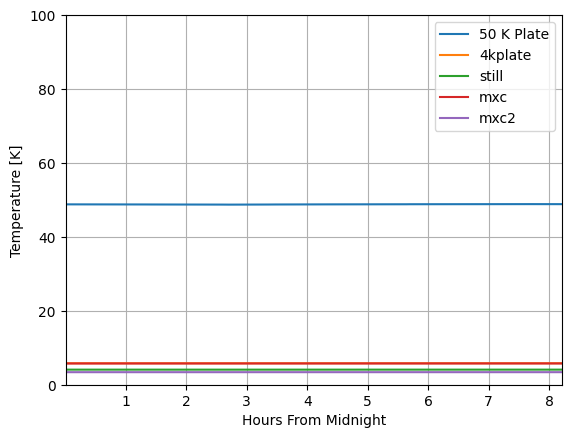

In [55]:
plt.plot(np.array(logdata['50kplate']['time'])/3600,np.array(logdata['50kplate']['temperature']))
plt.plot(np.array(logdata['4kplate']['time'])/3600,np.array(logdata['4kplate']['temperature']))
plt.plot(np.array(logdata['still']['time'])/3600,np.array(logdata['still']['temperature']))
plt.plot(np.array(logdata['mxc']['time'])/3600,np.array(logdata['mxc']['temperature']))
plt.plot(np.array(logdata['mxc2']['time'])/3600,np.array(logdata['mxc2']['temperature']))

plt.ylim([0,100])
plt.xlim([logdata['50kplate']['time'][0]/3600,logdata['50kplate']['time'][len(logdata['50kplate']['time']) - 1]/3600])
plt.grid()
plt.xlabel('Hours From Midnight')
plt.ylabel('Temperature [K]')
plt.legend(['50 K Plate','4kplate','still','mxc','mxc2'])